# criticality_msb — interactive analysis

Reads the pre-computed dataset in `criticality_msb/data/` and derives the MSB observables — **no
re-simulation**. The expensive integration lives in `simulate.py` (run once); everything here is a cheap
re-read of the stored per-firm log-abundance, so the analysis horizon Δt, the extinction/listing rule,
and the size normalization are all knobs you turn *here*.

Toolkit: `criticality_msb.observables` (Moran size, β, growth, tails, extinction) over
`criticality_msb.dataset` (the npz loader). Edit the knobs (`DT`, `ALIVE`, `F0`) and re-run any cell.

In [2]:
import sys, os
# make the criticality_msb package importable regardless of where the notebook is launched
_p = os.path.abspath(os.getcwd())
while _p != os.path.dirname(_p) and not os.path.isfile(os.path.join(_p, "criticality_msb", "observables.py")):
    _p = os.path.dirname(_p)
if _p not in sys.path:
    sys.path.insert(0, _p)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew

from criticality_msb import config as C
from criticality_msb.dataset import load_runs, f_values
from criticality_msb import observables as O

# ---- REGIME + analysis knobs (change and re-run) ----
# The dataset mixes regimes (base μ=4/λ=0, the μ-scan, the immigration sweeps), so pick ONE here.
MU, LAM = 4.0, 0.0     # 4.0/0.0 = base grid;  e.g. LAM=0.01 = the immigration candidate
DT = 1.0               # growth horizon (multiple of dt_store)
ALIVE = 1e-4           # persistence / listing threshold
F0 = 0.9               # near-critical f for single-f panels

runs = load_runs(C.DATA_DIR, mu=MU, lam=LAM)
fs = f_values(runs)
print(f"regime μ={MU}, λ={LAM}:  {len(runs)} runs   f={fs}   seeds={len({r.seed for r in runs})}")
if runs:
    print(f"σ_c ∈ [{min(r.sigma_c for r in runs):.3f}, {max(r.sigma_c for r in runs):.3f}]   diverged {sum(r.diverged for r in runs)}/{len(runs)}")


def per_f(fn):
    out = {}
    for f in fs:
        v = np.array([fn(r) for r in runs if abs(r.f - f) < 1e-9 and not r.diverged])
        v = v[np.isfinite(v)]
        out[f] = (v.mean(), v.std(), v.size) if v.size else (np.nan, np.nan, 0)
    return out


def pool_growth(f, dt=DT, persistent=False, alive=ALIVE):
    gs = []
    for r in runs:
        if abs(r.f - f) > 1e-9 or r.diverged:
            continue
        _, g = O.growth(r, dt=dt)
        if persistent:
            g = g[O.persistent_mask(r, alive=alive)]
        gs.append(g.ravel())
    g = np.concatenate(gs) if gs else np.array([])
    return g[np.isfinite(g)]


def band(ax, d, **kw):
    m = np.array([d[f][0] for f in fs]); s = np.array([d[f][1] for f in fs])
    ax.plot(fs, m, **kw)
    ax.fill_between(fs, m - s, m + s, alpha=0.15, color=kw.get("color"))

regime μ=4.0, λ=0.0:  400 runs   f=[0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95]   seeds=50
σ_c ∈ [1.869, 2.475]   diverged 3/400


## β and survival vs criticality (±1σ over 50 seeds)

The size–volatility exponent β for all firms vs persistent (listed) firms, and the survivor fraction,
each with seed-to-seed error bands. β_persist is the floor-insensitive measure; the all-firms β near
σ_c is crash-dominated (most firms have crashed — see the survival panel).

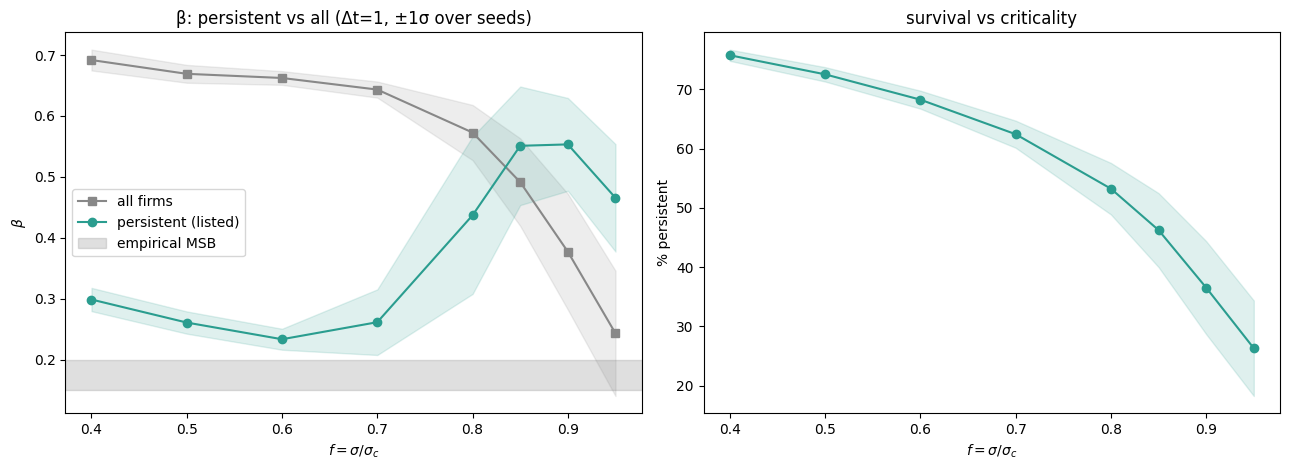

     f    β_all   β_persist  %persist
  0.40    0.692   0.299±0.02        76
  0.50    0.669   0.261±0.02        73
  0.60    0.662   0.233±0.02        68
  0.70    0.643   0.261±0.05        62
  0.80    0.573   0.437±0.13        53
  0.85    0.491   0.551±0.10        46
  0.90    0.377   0.553±0.08        37
  0.95    0.243   0.466±0.09        26


In [3]:
b_all = per_f(lambda r: O.beta_fit(*O.size_volatility(r, dt=DT)))
b_per = per_f(lambda r: O.beta_fit(*O.size_volatility(r, dt=DT), mask=O.persistent_mask(r, alive=ALIVE)))
surv = per_f(lambda r: 100 * O.extinction_fractions(r, alive=ALIVE)["persist"])

fig, (axB, axS) = plt.subplots(1, 2, figsize=(13, 4.8))
band(axB, b_all, marker="s", color="#888", label="all firms")
band(axB, b_per, marker="o", color="#2a9d8f", label="persistent (listed)")
axB.axhspan(0.15, 0.20, color="gray", alpha=0.25, label="empirical MSB")
axB.set(xlabel=r"$f=\sigma/\sigma_c$", ylabel=r"$\beta$", title=f"β: persistent vs all (Δt={DT:g}, ±1σ over seeds)")
axB.legend()
band(axS, surv, marker="o", color="#2a9d8f")
axS.set(xlabel=r"$f=\sigma/\sigma_c$", ylabel="% persistent", title="survival vs criticality")
plt.tight_layout(); plt.show()

print(f"{'f':>6}{'β_all':>9}{'β_persist':>12}{'%persist':>10}")
for f in fs:
    print(f"{f:>6.2f}{b_all[f][0]:>9.3f}{b_per[f][0]:>8.3f}±{b_per[f][1]:<3.2f}{surv[f][0]:>10.0f}")

## Growth distribution — the tent is on the listed firms

At a near-critical f, the all-firms growth PDF is one-sided (crash-dominated), but conditioning on
persistent/listed firms recovers a roughly symmetric, fat-tailed tent. The table tracks the
persistent-firm skew and robust tail (99.9pct/MAD; Laplace≈10) across f — the tail stays heavy, the
skew collapses toward symmetric approaching σ_c.

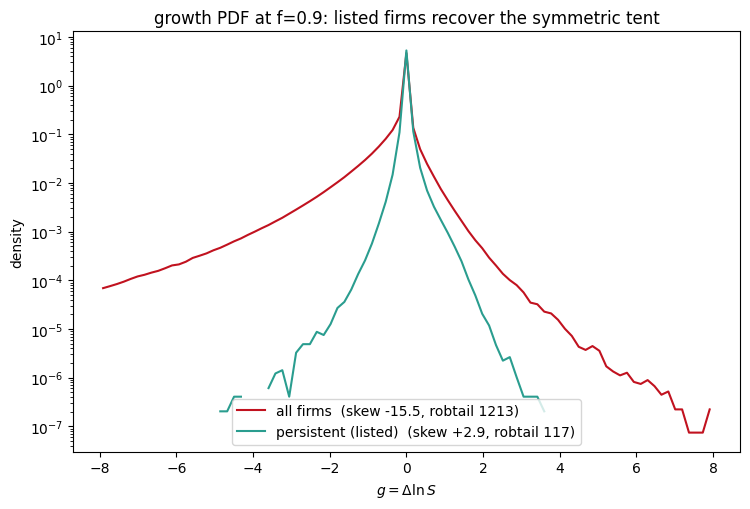

persistent-firm growth by f (Δt=1):
     f    skew   exkurt  robtail
  0.40  +15.34      883   151589
  0.50  +13.51      906    82458
  0.60  +10.22      937    30864
  0.70   +7.26      755     4199
  0.80   +4.36      438      472
  0.85   +3.58      257      192
  0.90   +2.90      144      117
  0.95   +1.85      159       86


In [4]:
e = np.linspace(-8, 8, 90); cc = 0.5 * (e[:-1] + e[1:])
fig, ax = plt.subplots(figsize=(7.6, 5.2))
for persistent, col, lab in [(False, "#c1121f", "all firms"), (True, "#2a9d8f", "persistent (listed)")]:
    g = pool_growth(F0, persistent=persistent)
    d, _ = np.histogram(g, bins=e, density=True)
    ax.semilogy(cc, np.where(d > 0, d, np.nan), "-", color=col,
                label=f"{lab}  (skew {O.tail_metrics(g)['skew']:+.1f}, robtail {O.tail_metrics(g)['robtail']:.0f})")
ax.set(xlabel=r"$g=\Delta\ln S$", ylabel="density",
       title=f"growth PDF at f={F0}: listed firms recover the symmetric tent")
ax.legend(); plt.tight_layout(); plt.show()

print(f"persistent-firm growth by f (Δt={DT:g}):")
print(f"{'f':>6}{'skew':>8}{'exkurt':>9}{'robtail':>9}")
for f in fs:
    m = O.tail_metrics(pool_growth(f, persistent=True))
    print(f"{f:>6.2f}{m['skew']:>+8.2f}{m['exkurt']:>9.0f}{m['robtail']:>9.0f}")

## Δt-robustness of the tail — kurtosis lies, the quantile metric doesn't

Re-derive the growth distribution at a near-critical f over a sweep of horizons Δt (a free re-read of
the same dataset). Excess kurtosis swings by orders of magnitude with Δt (it's dominated by the rarest
outliers, which aggregation washes out) — it is **sampling-defined**. The robust 99.9pct/MAD tail is
**flat in Δt** — the genuine, heavy, horizon-invariant fat-tailedness. Read tails with the quantile
metric, never bare kurtosis at an unstated Δt.

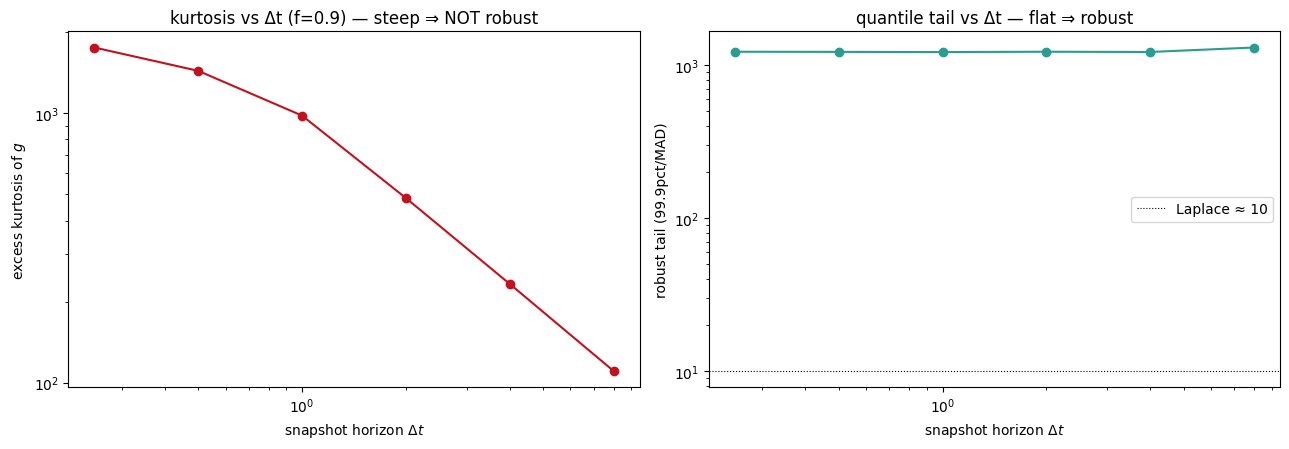

Δt      : [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
kurtosis: ['1757', '1439', '981', '485', '233', '110']
robtail : ['1219', '1216', '1213', '1219', '1214', '1299']


In [5]:
DTS = [d for d in [0.25, 0.5, 1.0, 2.0, 4.0, 8.0] if d >= runs[0].dt_store - 1e-9]
ek, rt = [], []
for dt in DTS:
    g = pool_growth(F0, dt=dt)
    ek.append(float(kurtosis(g)))
    rt.append(O.robtail(g))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
a1.loglog(DTS, ek, "o-", color="#c1121f")
a1.set(xlabel=r"snapshot horizon $\Delta t$", ylabel="excess kurtosis of $g$",
       title=f"kurtosis vs Δt (f={F0}) — steep ⇒ NOT robust")
a2.loglog(DTS, rt, "o-", color="#2a9d8f")
a2.axhline(10, color="k", ls=":", lw=0.8, label="Laplace ≈ 10")
a2.set(xlabel=r"snapshot horizon $\Delta t$", ylabel="robust tail (99.9pct/MAD)",
       title="quantile tail vs Δt — flat ⇒ robust")
a2.legend(); plt.tight_layout(); plt.show()

print("Δt      :", DTS)
print("kurtosis:", [f"{v:.0f}" for v in ek])
print("robtail :", [f"{v:.0f}" for v in rt])

## Diagnostics — trajectories, the fit, and the growth PDF

A full-size look at one regime: raw-abundance **trajectories** (one realization, between the immigration
floor λ and carrying capacity ~1), the **size–volatility fit** (faithful permanent-delist listing, floor=λ,
against the empirical β=0.204), and the **growth-rate PDF** (vs Gaussian/Laplace). Set `FD`, `LAMD` below
and re-run to inspect any (f, λ) — e.g. the candidate match is `FD="0.95", LAMD=1e-2`.

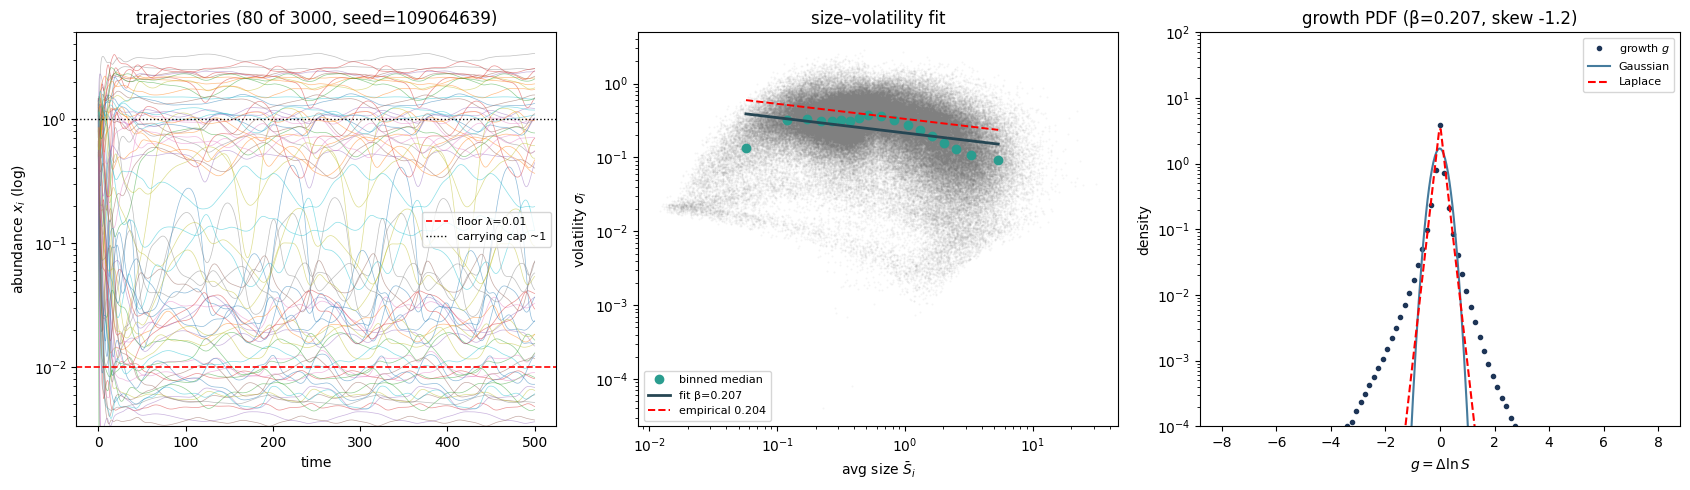

f=0.95, λ=0.01, floor=λ:  β=0.207 (empirical 0.204)   skew=-1.16   robtail=39


In [7]:
FD, LAMD = "0.95", 1e-2                 # diagnostic regime: f and λ (the candidate match). Change + re-run.
druns = load_runs(C.DATA_DIR, mu=4.0, lam=LAMD, f=float(FD))
r0 = druns[0]
fig = plt.figure(figsize=(17, 5))

# A — raw-abundance trajectories (one realization)
axA = fig.add_subplot(1, 3, 1)
x = np.exp(r0.logx)
idx = np.random.default_rng(0).choice(x.shape[0], 80, replace=False)
axA.semilogy(r0.t_snap, x[idx].T, lw=0.5, alpha=0.5)
axA.axhline(LAMD, color="r", ls="--", lw=1.2, label=f"floor λ={LAMD:g}")
axA.axhline(1.0, color="k", ls=":", lw=1, label="carrying cap ~1")
axA.set(xlabel="time", ylabel=r"abundance $x_i$ (log)", ylim=(LAMD / 3, 5),
        title=f"trajectories (80 of {x.shape[0]}, seed={r0.seed})")
axA.legend(fontsize=8)

# B — size-volatility fit (faithful listing, floor=λ)
axB = fig.add_subplot(1, 3, 2)
Sb, Vl = [], []
for r in druns:
    s, v = O.delisted_size_volatility(r, dt=1.0, floor=LAMD, min_growths=2)
    Sb.append(s); Vl.append(v)
Sb = np.concatenate(Sb); Vl = np.concatenate(Vl)
keep = (Sb > 0) & (Vl > 0) & np.isfinite(Vl); Sb, Vl = Sb[keep], Vl[keep]
o = np.argsort(Sb); xs, ys = Sb[o], Vl[o]; parts = np.array_split(np.arange(len(xs)), 18)
bx = np.array([xs[p].mean() for p in parts]); by = np.array([np.median(ys[p]) for p in parts])
m = (bx > 0) & (by > 0); coef = np.polyfit(np.log10(bx[m]), np.log10(by[m]), 1); beta = -coef[0]; mid = m.sum() // 2
axB.loglog(Sb, Vl, ".", ms=1, alpha=0.08, color="gray")
axB.loglog(bx[m], by[m], "o", ms=6, color="#2a9d8f", label="binned median")
axB.loglog(bx[m], 10 ** np.polyval(coef, np.log10(bx[m])), "-", color="#264653", lw=2, label=fr"fit β={beta:.3f}")
axB.loglog(bx[m], by[m][mid] * (bx[m] / bx[m][mid]) ** (-0.204), "r--", lw=1.4, label="empirical 0.204")
axB.set(xlabel=r"avg size $\bar S_i$", ylabel=r"volatility $\sigma_i$", title="size–volatility fit"); axB.legend(fontsize=8)

# C — growth-rate PDF
axC = fig.add_subplot(1, 3, 3)
g = np.concatenate([O.delisted_growth(r, dt=1.0, floor=LAMD, min_growths=2) for r in druns]); g = g[np.isfinite(g)]
gd = g[np.abs(g) < 10]
e = np.linspace(-8, 8, 100); cc = 0.5 * (e[:-1] + e[1:]); d, _ = np.histogram(gd, bins=e, density=True)
axC.semilogy(cc, np.where(d > 0, d, np.nan), "o", ms=3, color="#1d3557", label="growth $g$")
xx = np.linspace(-8, 8, 300); sd = gd.std(); med = np.median(gd); bl = np.mean(np.abs(gd - med))
axC.semilogy(xx, np.exp(-0.5 * ((xx - gd.mean()) / sd) ** 2) / (sd * np.sqrt(2 * np.pi)), color="#457b9d", label="Gaussian")
axC.semilogy(xx, np.exp(-np.abs(xx - med) / bl) / (2 * bl), "r--", label="Laplace")
axC.set_ylim(10**-4, 100)
axC.set(xlabel=r"$g=\Delta\ln S$", ylabel="density", title=f"growth PDF (β={beta:.3f}, skew {skew(g):+.1f})"); axC.legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f"f={FD}, λ={LAMD:g}, floor=λ:  β={beta:.3f} (empirical 0.204)   skew={skew(g):+.2f}   robtail={O.robtail(g):.0f}")

## Notes

- **Everything above is a re-read of `data/`** — change `DT`, `ALIVE`, or `F0` in the setup cell and
  re-run; no re-simulation. New observables go in `criticality_msb/observables.py` and are reusable
  from here *and* from `analyze_msb.py`.
- **Grow the dataset** (topology / S / γ / λ slices) by editing `criticality_msb/config.py` and running
  `python -m criticality_msb.simulate` — existing runs are skipped, then re-run this notebook.
- The batch script `analyze_msb.py` produces the static overview figure; this notebook is the
  interactive surface for exploring the same toolkit.